# Kinetic and canonic momentum comparison with or without Coulomb gauge

### Simulation parameters

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 1.0      
N = 128
# N = 256
tau_sim = 0.3
# DTS = 4
DTS = 16

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.2
g2mu = 1.5

g = 2         		
mu = g2mu / g**2

ns = 50      

nevents = 1
quark = 'jet' # 'jet' or 'static'            
# quark = 'static'

# coulomb_gauge_mode = 'every_step' # 'none' or 'every_step' or 'initial'
coulomb_gauge_mode = 'initial'

### Enviroment variables

In [2]:
import os

os.environ["MY_NUMBA_TARGET"] = "numba"
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

# Comment this, I need it for JYU GPUs to choose a specific GPU to run on
# os.environ["CUDA_VISIBLE_DEVICES"]="1"
# os.environ["MY_NUMBA_TARGET"] = "cuda"

os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Qhat module
if quark=='jet':
    import curraun.qhat_qeik as qeik
    import curraun.qhat_original as qhat
    # import curraun.qhat_qeik_old as qeik
elif quark=='static':
    import curraun.kappa_qeik as qeik
    import curraun.kappa as qhat

import curraun.coulomb as coulomb
coulomb.DEBUG = False

from tqdm import tqdm

Using Numba
Using SU(3)
Using double precision


In [3]:
def simulate_qhat(ev, coulomb_gauge_mode='none'): 
    """
    Run qhat simulation with optional Coulomb gauge fixing.
    
    Parameters:
    -----------
    ev : int
        Event number for progress display
    coulomb_gauge_mode : str
        'none' - no Coulomb gauge fixing
        'initial' - apply Coulomb gauge only at initial time (tint=tstart, when a0 is computed)
        'every_step' - apply Coulomb gauge at every timestep
    """
    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    mv.set_seed(314)
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Qhat module
    qeik_tforce = qeik.KineticCanonicCheck(s)  
    tau = []
    dpcan_sq, dpkin_sq, da_sq = [], [], []
    da_transp_sq, dpcanda, dpcanda_transp = [], [], []
    intfa, da = [], []

    qhat_tforce = qhat.TransportedForce(s)
    mom_broad =  []

    # Create CUDA stream for asynchronous execution
    stream = None
    if use_cuda:
        stream = cuda.stream()
        s.copy_to_device()
        qeik_tforce.copy_to_device()
        qhat_tforce.copy_to_device()

    # Determine gauge label for progress bar
    gauge_labels = {
        'none': 'no Coulomb',
        'initial': 'Coulomb at t=1',
        'every_step': 'Coulomb every step'
    }
    gauge_label = gauge_labels.get(coulomb_gauge_mode, coulomb_gauge_mode)
    
    # For 'initial' mode, we apply Coulomb gauge at tint=tstart (when a0 is computed)
    # This is when s.t = 1.0, which happens at loop iteration t = DTS
    tstart = DTS  # This is when tint == tstart in qeik_tforce.compute()
    
    with tqdm(total=maxt, desc=f"Event {ev+1} ({gauge_label})") as pbar:
        for t in range(maxt):
            # Apply Coulomb gauge transformation based on mode
            # For 'initial' mode, apply at t=DTS (when s.t=1.0 and a0 will be computed)
            apply_coulomb = (
                (coulomb_gauge_mode == 'every_step') or 
                (coulomb_gauge_mode == 'initial' and t == tstart)
            )
            
            if apply_coulomb:
                # Create Coulomb gauge transformation object
                c = coulomb.CoulombGaugeTransf(s)
                
                # Copy c to device if using CUDA (s is already on device)
                if use_cuda:
                    c.copy_to_device()
                
                # Perform gauge fixing entirely on GPU (or CPU if use_cuda=False)
                coulomb.gauge_fix(c, qeik_tforce=qeik_tforce)
                
                # No need to copy back - everything stays on device
            
            qeik_tforce.compute(stream)
            qhat_tforce.compute(stream)
            
            if t % DTS == 0:
                # Synchronize stream before copying to host
                if use_cuda:
                    stream.synchronize()
                    qeik_tforce.copy_to_host()
                    qhat_tforce.copy_mean_to_host()

                # Units GeV^2
                dpcan_sq.append(qeik_tforce.dpcan_sq_mean * E0 ** 2)
                dpkin_sq.append(qeik_tforce.dpkin_sq_mean * E0 ** 2)
                da_sq.append(qeik_tforce.da_sq_mean * E0 ** 2)
                da_transp_sq.append(qeik_tforce.da_transp_sq_mean * E0 ** 2)
                dpcanda.append(qeik_tforce.dpcanda_mean * E0 ** 2)
                dpcanda_transp.append(qeik_tforce.dpcanda_transp_mean * E0 ** 2)
                # tau = t * a / DTS
                tau.append(t*a/DTS)

                mom_broad.append(qhat_tforce.p_perp_mean * E0 ** 2)

                # No units
                intfa_sim = qeik_tforce.intfa.copy()
                intfa.append(intfa_sim[:, :, :])
                da_sim = qeik_tforce.da.copy()
                da.append(da_sim[:, :, :])

                if use_cuda:
                    qeik_tforce.copy_to_device()
                    qhat_tforce.copy_mean_to_device()
            
            # Evolve Glasma fields
            core.evolve_leapfrog(s, stream)

            pbar.update(1)
    
    if use_cuda:
        cuda.current_context().deallocations.clear()

    return np.array(tau), dpcan_sq, dpkin_sq, da_sq, da_transp_sq, dpcanda, dpcanda_transp, np.array(intfa), np.array(da), mom_broad

In [4]:
# Run simulations without Coulomb gauge
print("Running simulations WITHOUT Coulomb gauge transformation")

collect_dpcan_sq_no_coulomb, collect_dpkin_sq_no_coulomb = [], []
collect_da_sq_no_coulomb, collect_da_transp_sq_no_coulomb = [], []
collect_dpcanda_no_coulomb, collect_dpcanda_transp_no_coulomb = [], []
collect_mom_broad_no_coulomb = []

for ev in range(nevents): 
    tau, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_no_coulomb, da_no_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode='none')

    collect_dpcan_sq_no_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_no_coulomb.append(dpkin_sq_ev)
    collect_da_sq_no_coulomb.append(da_sq_ev)
    collect_da_transp_sq_no_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_no_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_no_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_no_coulomb.append(mom_broad_ev)

dpcan_sq_no_coulomb = np.mean(collect_dpcan_sq_no_coulomb, axis=0)
dpkin_sq_no_coulomb = np.mean(collect_dpkin_sq_no_coulomb, axis=0)
da_sq_no_coulomb = np.mean(collect_da_sq_no_coulomb, axis=0)
da_transp_sq_no_coulomb = np.mean(collect_da_transp_sq_no_coulomb, axis=0)
dpcanda_no_coulomb = np.mean(collect_dpcanda_no_coulomb, axis=0)
dpcanda_transp_no_coulomb = np.mean(collect_dpcanda_transp_no_coulomb, axis=0)  
mom_broad_no_coulomb = np.mean(collect_mom_broad_no_coulomb, axis=0)

Running simulations WITHOUT Coulomb gauge transformation


Event 1 (no Coulomb): 100%|██████████| 614/614 [00:11<00:00, 55.61it/s] 


In [5]:
# Run simulations with Coulomb gauge (mode from cell-2)
print(f"Running simulations WITH Coulomb gauge transformation (mode: {coulomb_gauge_mode})")

collect_dpcan_sq_coulomb, collect_dpkin_sq_coulomb = [], []
collect_da_sq_coulomb, collect_da_transp_sq_coulomb = [], []
collect_dpcanda_coulomb, collect_dpcanda_transp_coulomb = [], []
collect_mom_broad_coulomb = []

for ev in range(nevents): 
    tau, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_coulomb, da_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode)

    collect_dpcan_sq_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_coulomb.append(dpkin_sq_ev)
    collect_da_sq_coulomb.append(da_sq_ev)
    collect_da_transp_sq_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_coulomb.append(mom_broad_ev)

dpcan_sq_coulomb = np.mean(collect_dpcan_sq_coulomb, axis=0)
dpkin_sq_coulomb = np.mean(collect_dpkin_sq_coulomb, axis=0)
da_sq_coulomb = np.mean(collect_da_sq_coulomb, axis=0)
da_transp_sq_coulomb = np.mean(collect_da_transp_sq_coulomb, axis=0)
dpcanda_coulomb = np.mean(collect_dpcanda_coulomb, axis=0)
dpcanda_transp_coulomb = np.mean(collect_dpcanda_transp_coulomb, axis=0)  
mom_broad_coulomb = np.mean(collect_mom_broad_coulomb, axis=0)

Running simulations WITH Coulomb gauge transformation (mode: initial)


Event 1 (Coulomb at t=1):   3%|▎         | 16/614 [00:12<00:16, 35.94it/s]

Coulomb gauge condition reached in 13549 iterations with theta=9.99e-13


Event 1 (Coulomb at t=1): 100%|██████████| 614/614 [01:42<00:00,  6.00it/s] 


---
### Comparison kinetic and canonic momentum broadening without and with Coulomb gauge

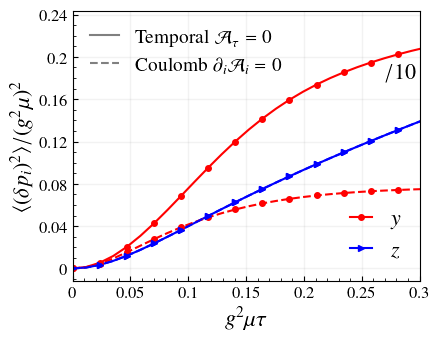

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

markers = ['o', 's']  # circle for y, square for z

# Division factors for each component
factor_y_no_coulomb = 10
factor_y_coulomb = 1
factor_z_no_coulomb = 1
factor_z_coulomb = 1

# Plot canonical momentum broadening
# Without Coulomb (temporal) - blue solid line
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, 1] / factor_y_no_coulomb / g2mu**2, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, 2] / factor_z_no_coulomb / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=5, markevery=2)

# With Coulomb - red dashed line
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, 1] / factor_y_coulomb / g2mu**2, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, 2] / factor_z_coulomb / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=5, markevery=2)

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
# ax.set_ylim([0, 0.2])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

# Set tick spacing (adjust independently for each axis)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.04))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta p_i)^2\rangle/ (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

# Text label (adjust coordinates as needed)
ax.text(0.9, 0.75, r'$/10$', transform=ax.transAxes, fontsize=16)

# Legend 1: y and z components (different markers)
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=4, linestyle='-', lw=1.5, label=r'$y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=5, linestyle='-', lw=1.5, label=r'$z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=16, frameon=False, loc='lower right', handlelength=1.0)

# Legend 2: Coulomb vs temporal (different colors + linestyles)
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$'),
]
ax.add_artist(legend1)
ax.legend(handles=legend2_elements, fontsize=14, frameon=False, loc='upper left', handlelength=1.5)

plt.tight_layout()
plt.savefig(f'pcan_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.pdf', facecolor='w')
plt.show()

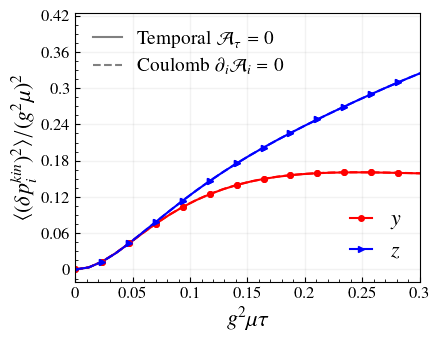

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

markers = ['o', 's']  # circle for y, square for z

# Division factors for each component
factor_y_no_coulomb = 1
factor_y_coulomb = 1
factor_z_no_coulomb = 1
factor_z_coulomb = 1

# Plot canonical momentum broadening
# Without Coulomb (temporal) - blue solid line
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, 1] / factor_y_no_coulomb / g2mu**2, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, 2] / factor_z_no_coulomb / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=5, markevery=2)

# With Coulomb - red dashed line
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, 1] / factor_y_coulomb / g2mu**2, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, 2] / factor_z_coulomb / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=5, markevery=2)

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
# ax.set_ylim([0, 0.2])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

# Set tick spacing (adjust independently for each axis)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.06))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta p_i^{kin})^2\rangle/ (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

# Text label (adjust coordinates as needed)
# ax.text(0.91, 0.85, r'$/10$', transform=ax.transAxes, fontsize=14)

# Legend 1: y and z components (different markers)
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=4, linestyle='-', lw=1.5, label=r'$y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=5, linestyle='-', lw=1.5, label=r'$z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=16, frameon=False, loc='lower right', handlelength=1.0)

# Legend 2: Coulomb vs temporal (different colors + linestyles)
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$'),
]
ax.add_artist(legend1)
ax.legend(handles=legend2_elements, fontsize=14, frameon=False, loc='upper left', handlelength=1.5)

plt.tight_layout()
plt.savefig(f'pkin_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.pdf', facecolor='w')
plt.show()

---
## Combined comparison plot

In [33]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker

# plt.rcParams['font.family'] = 'DejaVu Serif'
# plt.rcParams['font.serif'] = ['DejaVu Serif']
# plt.rcParams['mathtext.fontset'] = 'cm'

# fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# labels = ['x', 'y', 'z']
# directions = [1, 2]  # y and z
# direction_labels = ['y', 'z']

# for idx, i in enumerate(directions):
#     ax = axes[idx]
    
#     # Plot both pcan and pkin for without Coulomb
#     line1, = ax.plot(tau, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
#                      color='blue', label=rf'$p^{{\mathrm{{can}}}}$ (no Coulomb)')
#     line2, = ax.plot(tau, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
#                      color='green', label=rf'$p^{{\mathrm{{kin}}}}$ (no Coulomb)')
    
#     # Plot both pcan and pkin for with Coulomb
#     line3, = ax.plot(tau, dpcan_sq_coulomb[:, i], linewidth=2.0, 
#                      color='blue', linestyle='--', label=rf'$p^{{\mathrm{{can}}}}$ (with Coulomb)')
#     line4, = ax.plot(tau, dpkin_sq_coulomb[:, i], linewidth=2.0, 
#                      color='green', linestyle='--', label=rf'$p^{{\mathrm{{kin}}}}$ (with Coulomb)')
    
#     ax.set_xlim([0, max(tau)])
#     ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
#     ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
#     ax.set_xlabel(r"$\tau\,\mathrm{[fm]}$", fontsize=18)
#     ax.set_ylabel(rf"$\langle (\delta p_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
#     ax.set_title(f'{direction_labels[idx]} direction', fontsize=16)
#     ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
#     ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
#     ax.minorticks_on()
#     ax.tick_params(axis='both', which='minor', direction='in')
#     ax.legend(fontsize=12, frameon=False)

# plt.tight_layout()
# # plt.savefig(f'combined_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
# plt.show()

---
# Numerical checks
Compare the time-integrated Lorentz force that contribues to the gauge field, and the relative difference containing the parallel transported gauge field

$$\int_{\tau_0}^\tau \mathrm{d}\tau^\prime \tilde{f}^A_i(\tau^\prime)=\tilde{A}_i(\tau)-A_i(\tau_0)$$

where $\tilde{f}_i(\tau)=U(\tau,\tau_0)f_i U^\dagger(\tau,\tau_0)$ rotated with the Wilson line along the eikonal jet trajectory, and similarly for $\tilde{A}_i$. The Lorentz force contains
\begin{equation*}f_i^A=f_i^{p,\mathrm{can}}-f_i^{p,\mathrm{kin}}\end{equation*}
with the relevant components 
\begin{equation*}f_y^{p,\mathrm{can}}=-\partial_yA_x= -B_z^\mathrm{can},\quad f_z^{p,\mathrm{can}}=-\dfrac{1}{\tau^2} A_\eta = E_z^\mathrm{can}\end{equation*}
along with 
\begin{equation*}f_y^{p,\mathrm{kin}}=\dfrac{1}{\tau} P^y+F_{xy}= E_y^\mathrm{kin}-B_z^\mathrm{kin},\quad f_z^{p,\mathrm{kin}}=P^\eta+\dfrac{1}{\tau} D_xA_\eta=E_z^\mathrm{kin}+B_y^\mathrm{kin}\end{equation*}

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/3326295004.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('RdBu', 20)


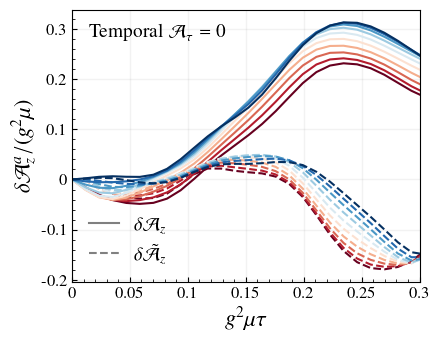

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ntraj = 10
cmap_rb = plt.cm.get_cmap('RdBu', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 2  # z direction
na = 3  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_no_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_no_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 0.3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\delta \mathcal{A}^a_z/(g^2\mu)$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_z$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_z$'),
]
ax.legend(handles=legend_elements, fontsize=14, frameon=False, loc='lower left', handlelength=1.5)

ax.text(0.05, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig(f'intfa_deltaa_z_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/849464801.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('RdBu', 20)


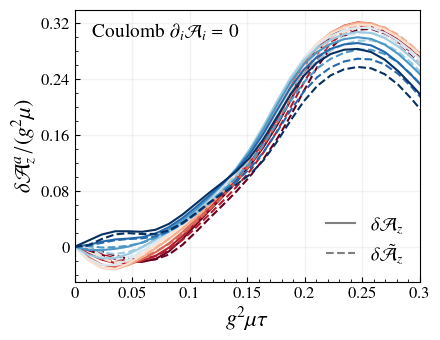

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ntraj = 10
cmap_rb = plt.cm.get_cmap('RdBu', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 2  # z direction
# na = 3  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 0.3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.08))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\delta \mathcal{A}^a_z/(g^2\mu)$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_z$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_z$'),
]
ax.legend(handles=legend_elements, fontsize=14, frameon=False, loc='lower right', handlelength=1.5)

ax.text(0.05, 0.9, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig(f'intfa_deltaa_z_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/2128779927.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('BrBG', 20)


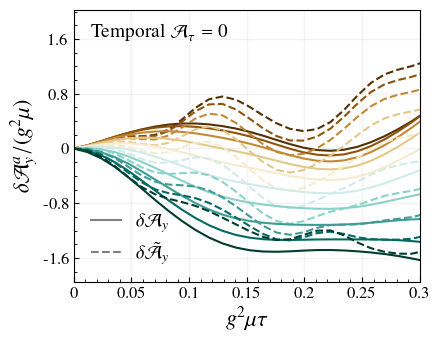

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ntraj = 10
cmap_rb = plt.cm.get_cmap('BrBG', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 1  # y direction
na = 0  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_no_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_no_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 0.3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.8))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\delta \mathcal{A}^a_y/(g^2\mu)$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_y$'),
]
ax.legend(handles=legend_elements, fontsize=14, frameon=False, loc='lower left', handlelength=1.5)

ax.text(0.05, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig(f'intfa_deltaa_y_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/2806509365.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('BrBG', 20)


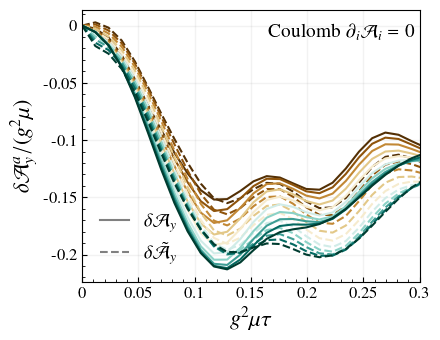

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
from curraun.su3 import get_algebra_factors_from_group_element_approximate

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ntraj = 10
cmap_rb = plt.cm.get_cmap('BrBG', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 1  # y direction
# na = 0  # algebra factor index (0-7 for SU(3))

# Extract algebra factors from group elements
def get_algebra_factor(data, traj_idx, direction, algebra_idx):
    """Extract algebra factor na from group element data for all time steps."""
    ntime = data.shape[0]
    result = np.zeros(ntime)
    for t in range(ntime):
        g = tuple(data[t, traj_idx, direction, :])  # get group element as tuple
        factors = get_algebra_factors_from_group_element_approximate(g)
        result[t] = factors[algebra_idx]
    return result

for j in range(ntraj):
    da_algebra = get_algebra_factor(da_coulomb, j, i, na)
    intfa_algebra = get_algebra_factor(intfa_coulomb, j, i, na)
    ax.plot(g2mu * tau, da_algebra * E0 / g2mu, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(g2mu * tau, intfa_algebra * E0 / g2mu, linewidth=1.5, color=colors[j])

# ax.set_xlim([0, max(tau)])
ax.set_xlim([0, 0.3])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\delta \mathcal{A}^a_y/(g^2\mu)$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\delta\mathcal{A}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\delta\tilde{\mathcal{A}}_y$'),
]
ax.legend(handles=legend_elements, fontsize=14, frameon=False, loc='lower left', handlelength=1.5)

ax.text(0.55, 0.9, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig(f'intfa_deltaa_y_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

---
### $\delta A$ vs $\delta\tilde{A}$ comparison

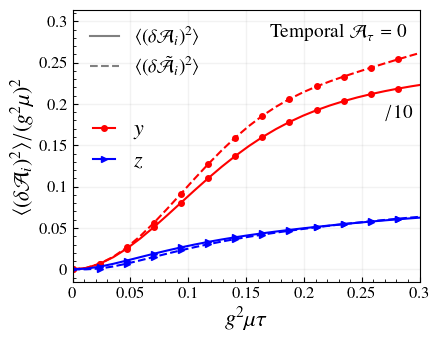

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# Without Coulomb gauge
i = 1  # y direction
factor = 10
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2 / factor, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2 / factor, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=4, markevery=2)

i = 2  # z direction
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=5, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=5, markevery=2)

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
# ax.set_ylim([-0.07, 0.32])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle / (g^2\mu)^2$", fontsize=16)
# ax.set_title(r'Without Coulomb gauge', fontsize=14)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

# Legend 1: y and z components
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=4, linestyle='-', lw=1.5, label=r'$y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=5, linestyle='-', lw=1.5, label=r'$z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=16, frameon=False, loc='center left', handlelength=1.0)

ax.text(0.57, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=14)
ax.text(0.9, 0.6, r'$/10$', transform=ax.transAxes, fontsize=14)

# Legend 2: A vs A tilde
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\langle (\delta \mathcal{A}_i)^2\rangle$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\langle (\delta \tilde{\mathcal{A}}_i)^2\rangle$'),
]
ax.add_artist(legend1)
ax.legend(handles=legend2_elements, fontsize=14, frameon=False, loc='upper left', handlelength=1.5)

plt.tight_layout()
plt.savefig(f'delta_a_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

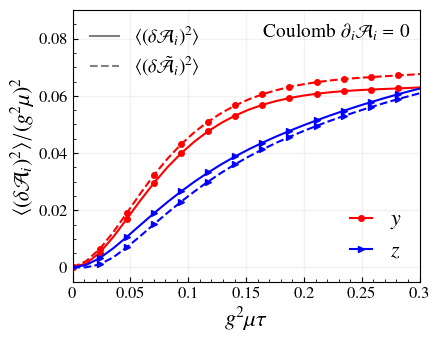

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# With Coulomb gauge
i = 1  # y direction
ax.plot(g2mu * tau, da_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='red', linestyle='-', marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='red', linestyle='--', marker='o', markersize=4, markevery=2)

i = 2  # z direction
ax.plot(g2mu * tau, da_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='-', marker='>', markersize=5, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, 
        color='blue', linestyle='--', marker='>', markersize=5, markevery=2)

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-0.005, 0.09])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle / (g^2\mu)^2$", fontsize=16)
# ax.set_title(r'With Coulomb gauge', fontsize=14)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

# Legend 1: y and z components
legend1_elements = [
    Line2D([0], [0], color='red', marker='o', markersize=4, linestyle='-', lw=1.5, label=r'$y$'),
    Line2D([0], [0], color='blue', marker='>', markersize=5, linestyle='-', lw=1.5, label=r'$z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=16, frameon=False, loc='lower right', handlelength=1.0)

ax.text(0.55, 0.9, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=14)

# Legend 2: A vs A tilde
legend2_elements = [
    Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label=r'$\langle (\delta \mathcal{A}_i)^2\rangle$'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1.5, label=r'$\langle (\delta \tilde{\mathcal{A}}_i)^2\rangle$'),
]
ax.add_artist(legend1)
ax.legend(handles=legend2_elements, fontsize=14, frameon=False, loc='upper left', handlelength=1.5)

plt.tight_layout()
plt.savefig(f'delta_a_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}.pdf', facecolor='w')
plt.show()

---
### Decomposition: $\langle (\delta p^{\mathrm{kin}})^2 \rangle = \langle (\delta p^{\mathrm{can}})^2 \rangle + \langle (\delta \mathcal{A})^2 \rangle + 2\langle \delta p^{\mathrm{can}} \delta \mathcal{A} \rangle$

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/549454888.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


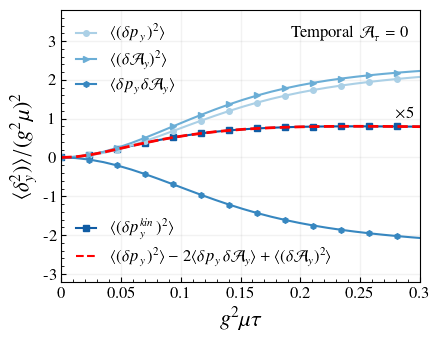

In [201]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 1  # y direction

factor = 5
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_sq_no_coulomb[:, i] + 2 * dpcanda_no_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-3.2, 3.8])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle / (g^2\mu)^2$", fontsize=16)
# ax.set_title(r'$y$ direction - Without Coulomb', fontsize=14)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \mathcal{A}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_y \,\delta \mathcal{A}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)  # Add first legend to keep it

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \mathcal{A}_y\rangle + \langle (\delta \mathcal{A}_y)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.64, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12)
ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'decomposition_y_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/2759700231.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


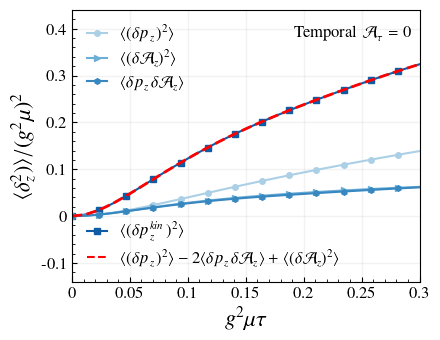

In [202]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_sq_no_coulomb[:, i] + 2 * dpcanda_no_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-0.14, 0.44])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle / (g^2\mu)^2$", fontsize=16)
# ax.set_title(r'$z$ direction - Without Coulomb', fontsize=14)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \mathcal{A}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_z \,\delta \mathcal{A}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)  # Add first legend to keep it

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \mathcal{A}_z\rangle + \langle (\delta \mathcal{A}_z)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.64, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12)
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'decomposition_z_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/1182847606.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


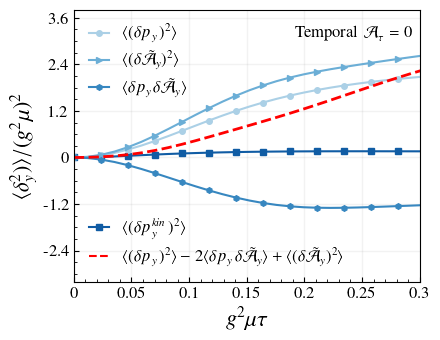

In [223]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 1  # y direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_transp_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_transp_sq_no_coulomb[:, i] + 2 * dpcanda_transp_no_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-3.2, 3.8])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(1.2))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle / (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle + \langle (\delta \tilde{\mathcal{A}}_y)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.64, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12)
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'decomposition_y_atilde_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/3498787969.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


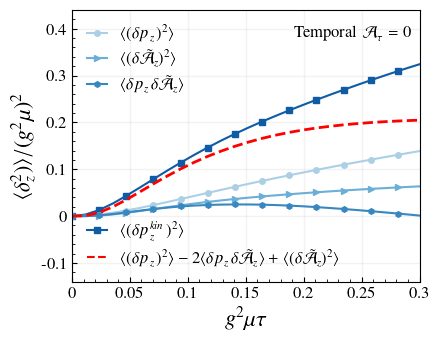

In [209]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_no_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_transp_no_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_no_coulomb[:, i] + da_transp_sq_no_coulomb[:, i] + 2 * dpcanda_transp_no_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-0.14, 0.44])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle / (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle + \langle (\delta \tilde{\mathcal{A}}_z)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.64, 0.9, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'decomposition_z_atilde_no_coulomb_{quark}_n_{N}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/4016182617.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


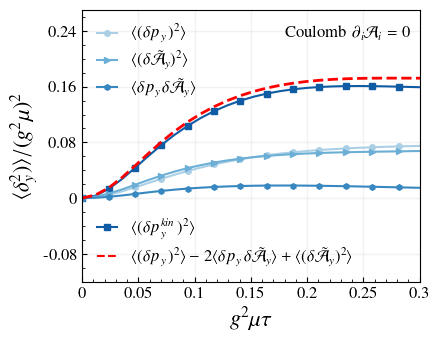

In [221]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 1  # y direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_transp_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_coulomb[:, i] + da_transp_sq_coulomb[:, i] + 2 * dpcanda_transp_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-0.12, 0.27])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.08))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_y)\rangle / (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_y\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_y\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_y\,)^2\rangle - 2\langle \delta p_y \,\delta \tilde{\mathcal{A}}_y\rangle + \langle (\delta \tilde{\mathcal{A}}_y)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.6, 0.9, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12)
# ax.text(0.93, 0.6, r'$\times 5$', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f'decomposition_y_atilde_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}.pdf', facecolor='w')
plt.show()

/var/folders/ty/xd7rkkkj7v342rv82wm67jcr0000gn/T/ipykernel_79935/1607473575.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rb = plt.cm.get_cmap('Blues', 7)


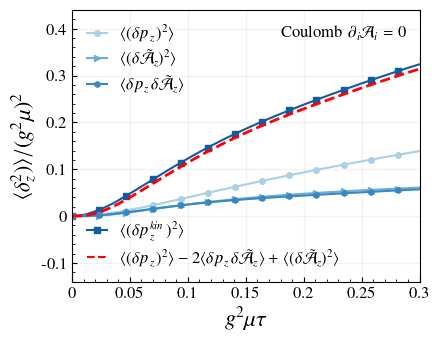

In [225]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

cmap_rb = plt.cm.get_cmap('Blues', 7)
colors = [cmap_rb(i) for i in np.linspace(0, 1, 7)]

fig, ax = plt.subplots(figsize=(4.5, 3.5))

i = 2  # z direction

factor = 1
ax.plot(g2mu * tau, dpkin_sq_coulomb[:, i] / g2mu**2 * factor, linewidth=1.5, color=colors[5], marker='s', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcan_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[2], marker='o', markersize=4, markevery=2)
ax.plot(g2mu * tau, da_transp_sq_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[3], marker='>', markersize=4, markevery=2)
ax.plot(g2mu * tau, dpcanda_transp_coulomb[:, i] / g2mu**2, linewidth=1.5, color=colors[4], marker='h', markersize=4, markevery=2)
# convention Alatt = -igaA, so mixed term delta p * delta A is with +
ax.plot(g2mu * tau, (dpcan_sq_coulomb[:, i] + da_transp_sq_coulomb[:, i] + 2 * dpcanda_transp_coulomb[:, i]) / g2mu**2 * factor, 
        linewidth=2, color='red', linestyle='--')

# ax.set_xlim([0, max(g2mu * tau)])
ax.set_xlim([0, 0.3])
ax.set_ylim([-0.14, 0.44])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=16)
ax.set_ylabel(r"$\langle \delta^2_z)\rangle / (g^2\mu)^2$", fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color=colors[2], lw=1.5, marker='o', markersize=4, label=r"$\langle (\delta p_z\,)^2\rangle$"),
    Line2D([0], [0], color=colors[3], lw=1.5, marker='>', markersize=4, label=r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle$"),
    Line2D([0], [0], color=colors[4], lw=1.5, marker='h', markersize=4, label=r"$\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle$"),
]
legend1 = ax.legend(handles=legend_elements, fontsize=12, frameon=False, loc='upper left', handlelength=1.2)
ax.add_artist(legend1)

legend_elements_2 = [
    Line2D([0], [0], color=colors[5], lw=1.5, marker='s', markersize=4, label=r"$\langle (\delta p^{kin}_z\,)^2\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"$\langle (\delta p_z\,)^2\rangle - 2\langle \delta p_z \,\delta \tilde{\mathcal{A}}_z\rangle + \langle (\delta \tilde{\mathcal{A}}_z)^2\rangle $"),
]
ax.legend(handles=legend_elements_2, fontsize=12, frameon=False, loc='lower left', handlelength=1.2)

ax.text(0.6, 0.9, r'$\mathrm{Coulomb}\,\,\partial_i\mathcal{A}_i=0$', transform=ax.transAxes, fontsize=12)
plt.tight_layout()
plt.savefig(f'decomposition_z_atilde_coulomb_{quark}_n_{N}_{coulomb_gauge_mode}.pdf', facecolor='w')
plt.show()

---